# Phase 1: Auto-Labeling — Perfume Reviews

**Task:** classify whether a reviewer liked a perfume (`liked` / `mixed` / `not_liked`)  
**Model:** `seara/rubert-tiny2-russian-sentiment` (~112 MB)  
**Data:** `data/cleaned/strategy_a.csv` — 807 reviews in Russian

In [1]:
import sys
sys.path.append('../src')

from transformers import pipeline
from labeling_utils import (
    load_data, run_auto_label, save_labeled,
    quality_summary, save_quality_report, label_distribution, uncertain_records
)
import pandas as pd

DATA_PATH = '../data/cleaned/strategy_a.csv'
LABELED_PATH = '../data/labeled/strategy_a_labeled.csv'
REPORT_PATH = '../data/reports/quality_metrics.json'

print('Libraries loaded OK')

Libraries loaded OK


## 1. Load model

In [2]:
print('Loading model seara/rubert-tiny2-russian-sentiment...')
classifier = pipeline(
    'sentiment-analysis',
    model='seara/rubert-tiny2-russian-sentiment',
    tokenizer='seara/rubert-tiny2-russian-sentiment',
)
print('Model loaded!')

Loading model seara/rubert-tiny2-russian-sentiment...


config.json:   0%|          | 0.00/911 [00:00<?, ?B/s]

C:\Users\denni\Desktop\git_repos\data-for-ml-itmo-2026\.venv\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\denni\.cache\huggingface\hub\models--seara--rubert-tiny2-russian-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/117M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use cpu


Model loaded!


## 2. Load data

In [3]:
rows = load_data(DATA_PATH)
print(f'Loaded {len(rows)} reviews')
print(f'Columns: {list(rows[0].keys())}')

Loaded 807 reviews
Columns: ['perfume_name', 'brand', 'rating', 'votes', 'top_notes', 'middle_notes', 'base_notes', 'reviewer', 'review_date', 'review_text']


## 3. Run auto-labeling

In [4]:
print('Running inference...')
labeled = run_auto_label(rows, classifier, batch_size=32)
print(f'Done! Labeled {len(labeled)} reviews')

Running inference...


Done! Labeled 807 reviews


## 4. Results overview

In [5]:
df = pd.DataFrame(labeled)
summary = quality_summary(labeled)

print('=== LABEL DISTRIBUTION ===')
for label, info in summary['distribution'].items():
    print(f'  {label:12s}: {info["count"]:4d} ({info["pct"]}%)')

print(f'\nMean confidence : {summary["mean_confidence"]}')
print(f'Uncertain (<0.5): {summary["uncertain_count"]} ({summary["uncertain_pct"]}%)')

=== LABEL DISTRIBUTION ===
  mixed       :  296 (36.7%)
  liked       :  464 (57.5%)
  not_liked   :   47 (5.8%)

Mean confidence : 0.7625
Uncertain (<0.5): 44 (5.5%)


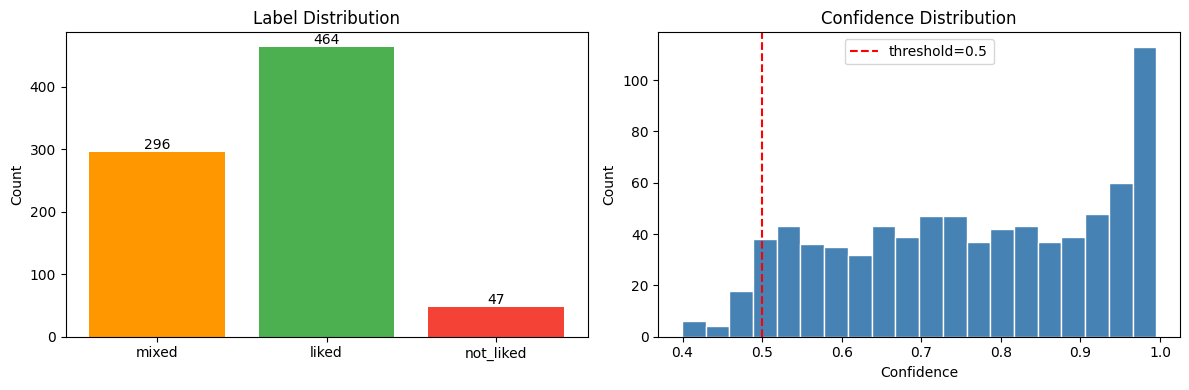

In [6]:
import matplotlib.pyplot as plt

dist = summary['distribution']
labels = list(dist.keys())
counts = [dist[l]['count'] for l in labels]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

colors = {'liked': '#4CAF50', 'mixed': '#FF9800', 'not_liked': '#F44336'}
bar_colors = [colors.get(l, '#888') for l in labels]
ax1.bar(labels, counts, color=bar_colors)
ax1.set_title('Label Distribution')
ax1.set_ylabel('Count')
for i, (l, c) in enumerate(zip(labels, counts)):
    ax1.text(i, c + 5, str(c), ha='center')

ax2.hist(df['confidence'].astype(float), bins=20, color='steelblue', edgecolor='white')
ax2.axvline(0.5, color='red', linestyle='--', label='threshold=0.5')
ax2.set_title('Confidence Distribution')
ax2.set_xlabel('Confidence')
ax2.set_ylabel('Count')
ax2.legend()

plt.tight_layout()
plt.savefig('../data/reports/label_distribution.png', dpi=100)
plt.show()

## 5. Sample predictions per class

In [7]:
for label in ['liked', 'mixed', 'not_liked']:
    subset = df[df['label'] == label].sort_values('confidence', ascending=False).head(2)
    print(f'\n=== {label.upper()} (top confidence) ===')
    for _, row in subset.iterrows():
        print(f'  [{row["confidence"]:.2f}] {row["perfume_name"]} — {row["review_text"][:200]}...')
        print()


=== LIKED (top confidence) ===
  [1.00] By the Fireplace — классный, маршмеллоу на огне. Зимний, очень уютный и красивый, мне очень понравился...

  [0.99] Acqua di Parma Colonia — буду краток. Отличный одеколон! Лаванда и розмарин отлично звучат....


=== MIXED (top confidence) ===
  [0.89] Cuoium — Подскажите, какой должен быть цвет парфюма, потому что видел темнокоричневого цвета и также видел светлого почти прозрачного, в чем разница кто знает?...

  [0.88] Cuoium — У меня парфюм ассоциируется с ведьмаком, с тем самым Геральтом из Ривии, из книг Сапковского....


=== NOT_LIKED (top confidence) ===
  [0.95] Cuoium — Я конечно все понимаю,но я этого не понимаю!Я просто из-за флакона подошла к нему иии…. мне дурно.??Кто хочет так пахнуть?Это мужик которому 45 и он курит обычные,вонючие сигы,причём у него уже стаж н...

  [0.93] Chanel No 5 Eau de Parfum — Был. Купила лет 15 назад в дьюти-фри 50 мл под девизом «если уж покупать духи, то надо покупать The Духи!!!». Ну и интересно было,

## 6. Uncertain examples

In [8]:
uncertain = uncertain_records(labeled, threshold=0.5)
print(f'Uncertain records (confidence < 0.5): {len(uncertain)}')
if uncertain:
    unc_df = pd.DataFrame(uncertain[:5])
    display(unc_df[['perfume_name', 'label', 'confidence', 'review_text']].assign(
        review_text=unc_df['review_text'].str[:150]
    ))

Uncertain records (confidence < 0.5): 44


,perfume_name,label,confidence,review_text
0,Chanel No 5 Eau de Parfum,mixed,0.4867,"Как любая классика, этот парфюм неизвестен бол..."
1,Chanel No 5 Eau de Parfum,mixed,0.4833,"Заполучил месяц назад пробничек EDP, по факту ..."
2,Cuoium,mixed,0.3992,Немного об этом чуде от Гуалтьери-брутален! Эт...
3,Cuoium,mixed,0.4044,Сегодня ребята обсуждали данный аромат в одном...
4,Cuoium,mixed,0.4976,Вонюче притягательно. Как запах секса. Он непр...


## 7. Save results

In [9]:
save_labeled(labeled, LABELED_PATH)
save_quality_report(summary, REPORT_PATH)
print(f'Saved: {LABELED_PATH}')
print(f'Saved: {REPORT_PATH}')

Saved: ../data/labeled/strategy_a_labeled.csv
Saved: ../data/reports/quality_metrics.json


## Summary

In [10]:
print('═' * 47)
print('📋 ФАЗА 1: AUTO LABEL — ЗАВЕРШЕНА')
print('═' * 47)
print(f'Размечено      : {summary["labeled"]} записей')
print(f'Классов        : 3 (liked / mixed / not_liked)')
print(f'Средний conf   : {summary["mean_confidence"]}')
print(f'Uncertain (<0.5): {summary["uncertain_count"]} ({summary["uncertain_pct"]}%)')
print('═' * 47)

═══════════════════════════════════════════════
📋 ФАЗА 1: AUTO LABEL — ЗАВЕРШЕНА
═══════════════════════════════════════════════
Размечено      : 807 записей
Классов        : 3 (liked / mixed / not_liked)
Средний conf   : 0.7625
Uncertain (<0.5): 44 (5.5%)
═══════════════════════════════════════════════
